# Gradient Boosting

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Create dataset

In [4]:

dataset_dict = {
   'Outlook': ['sunny', 'sunny', 'overcast', 'rain', 'rain', 'rain', 'overcast', 
               'sunny', 'sunny', 'rain', 'sunny', 'overcast', 'overcast', 'rain',
               'sunny', 'overcast', 'rain', 'sunny', 'sunny', 'rain', 'overcast',
               'rain', 'sunny', 'overcast', 'sunny', 'overcast', 'rain', 'overcast'],
   'Temp.': [85.0, 80.0, 83.0, 70.0, 68.0, 65.0, 64.0, 72.0, 69.0, 75.0, 75.0,
             72.0, 81.0, 71.0, 81.0, 74.0, 76.0, 78.0, 82.0, 67.0, 85.0, 73.0,
             88.0, 77.0, 79.0, 80.0, 66.0, 84.0],
   'Humid.': [85.0, 90.0, 78.0, 96.0, 80.0, 70.0, 65.0, 95.0, 70.0, 80.0, 70.0,
              90.0, 75.0, 80.0, 88.0, 92.0, 85.0, 75.0, 92.0, 90.0, 85.0, 88.0,
              65.0, 70.0, 60.0, 95.0, 70.0, 78.0],
   'Wind': [False, True, False, False, False, True, True, False, False, False, True,
            True, False, True, True, False, False, True, False, True, True, False,
            True, False, False, True, False, False],
   'Num_Players': [52, 39, 43, 37, 28, 19, 43, 47, 56, 33, 49, 23, 42, 13, 33, 29,
                   25, 51, 41, 14, 34, 29, 49, 36, 57, 21, 23, 41]
}

# Prepare data
df = pd.DataFrame(dataset_dict)
df = pd.get_dummies(df, columns=['Outlook'], prefix='', prefix_sep='')
df['Wind'] = df['Wind'].astype(int)
df

,Temp.,Humid.,Wind,Num_Players,overcast,rain,sunny
0,85.0,85.0,0,52,False,False,True
1,80.0,90.0,1,39,False,False,True
2,83.0,78.0,0,43,True,False,False
3,70.0,96.0,0,37,False,True,False
4,68.0,80.0,0,28,False,True,False
5,65.0,70.0,1,19,False,True,False
6,64.0,65.0,1,43,True,False,False
7,72.0,95.0,0,47,False,False,True
8,69.0,70.0,0,56,False,False,True
9,75.0,80.0,0,33,False,True,False


# Split features and target

In [6]:
X = df.drop('Num_Players', axis=1)
y = df['Num_Players']


# Split data into train  + test

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.5, shuffle=False)

In [8]:
print(X_train.shape)
print(X_test.shape)

(14, 6)
(14, 6)


In [9]:
from sklearn.ensemble import GradientBoostingRegressor

# Train the model
clf = GradientBoostingRegressor(criterion='squared_error', learning_rate=0.1, random_state=42)
clf.fit(X_train, y_train)


,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

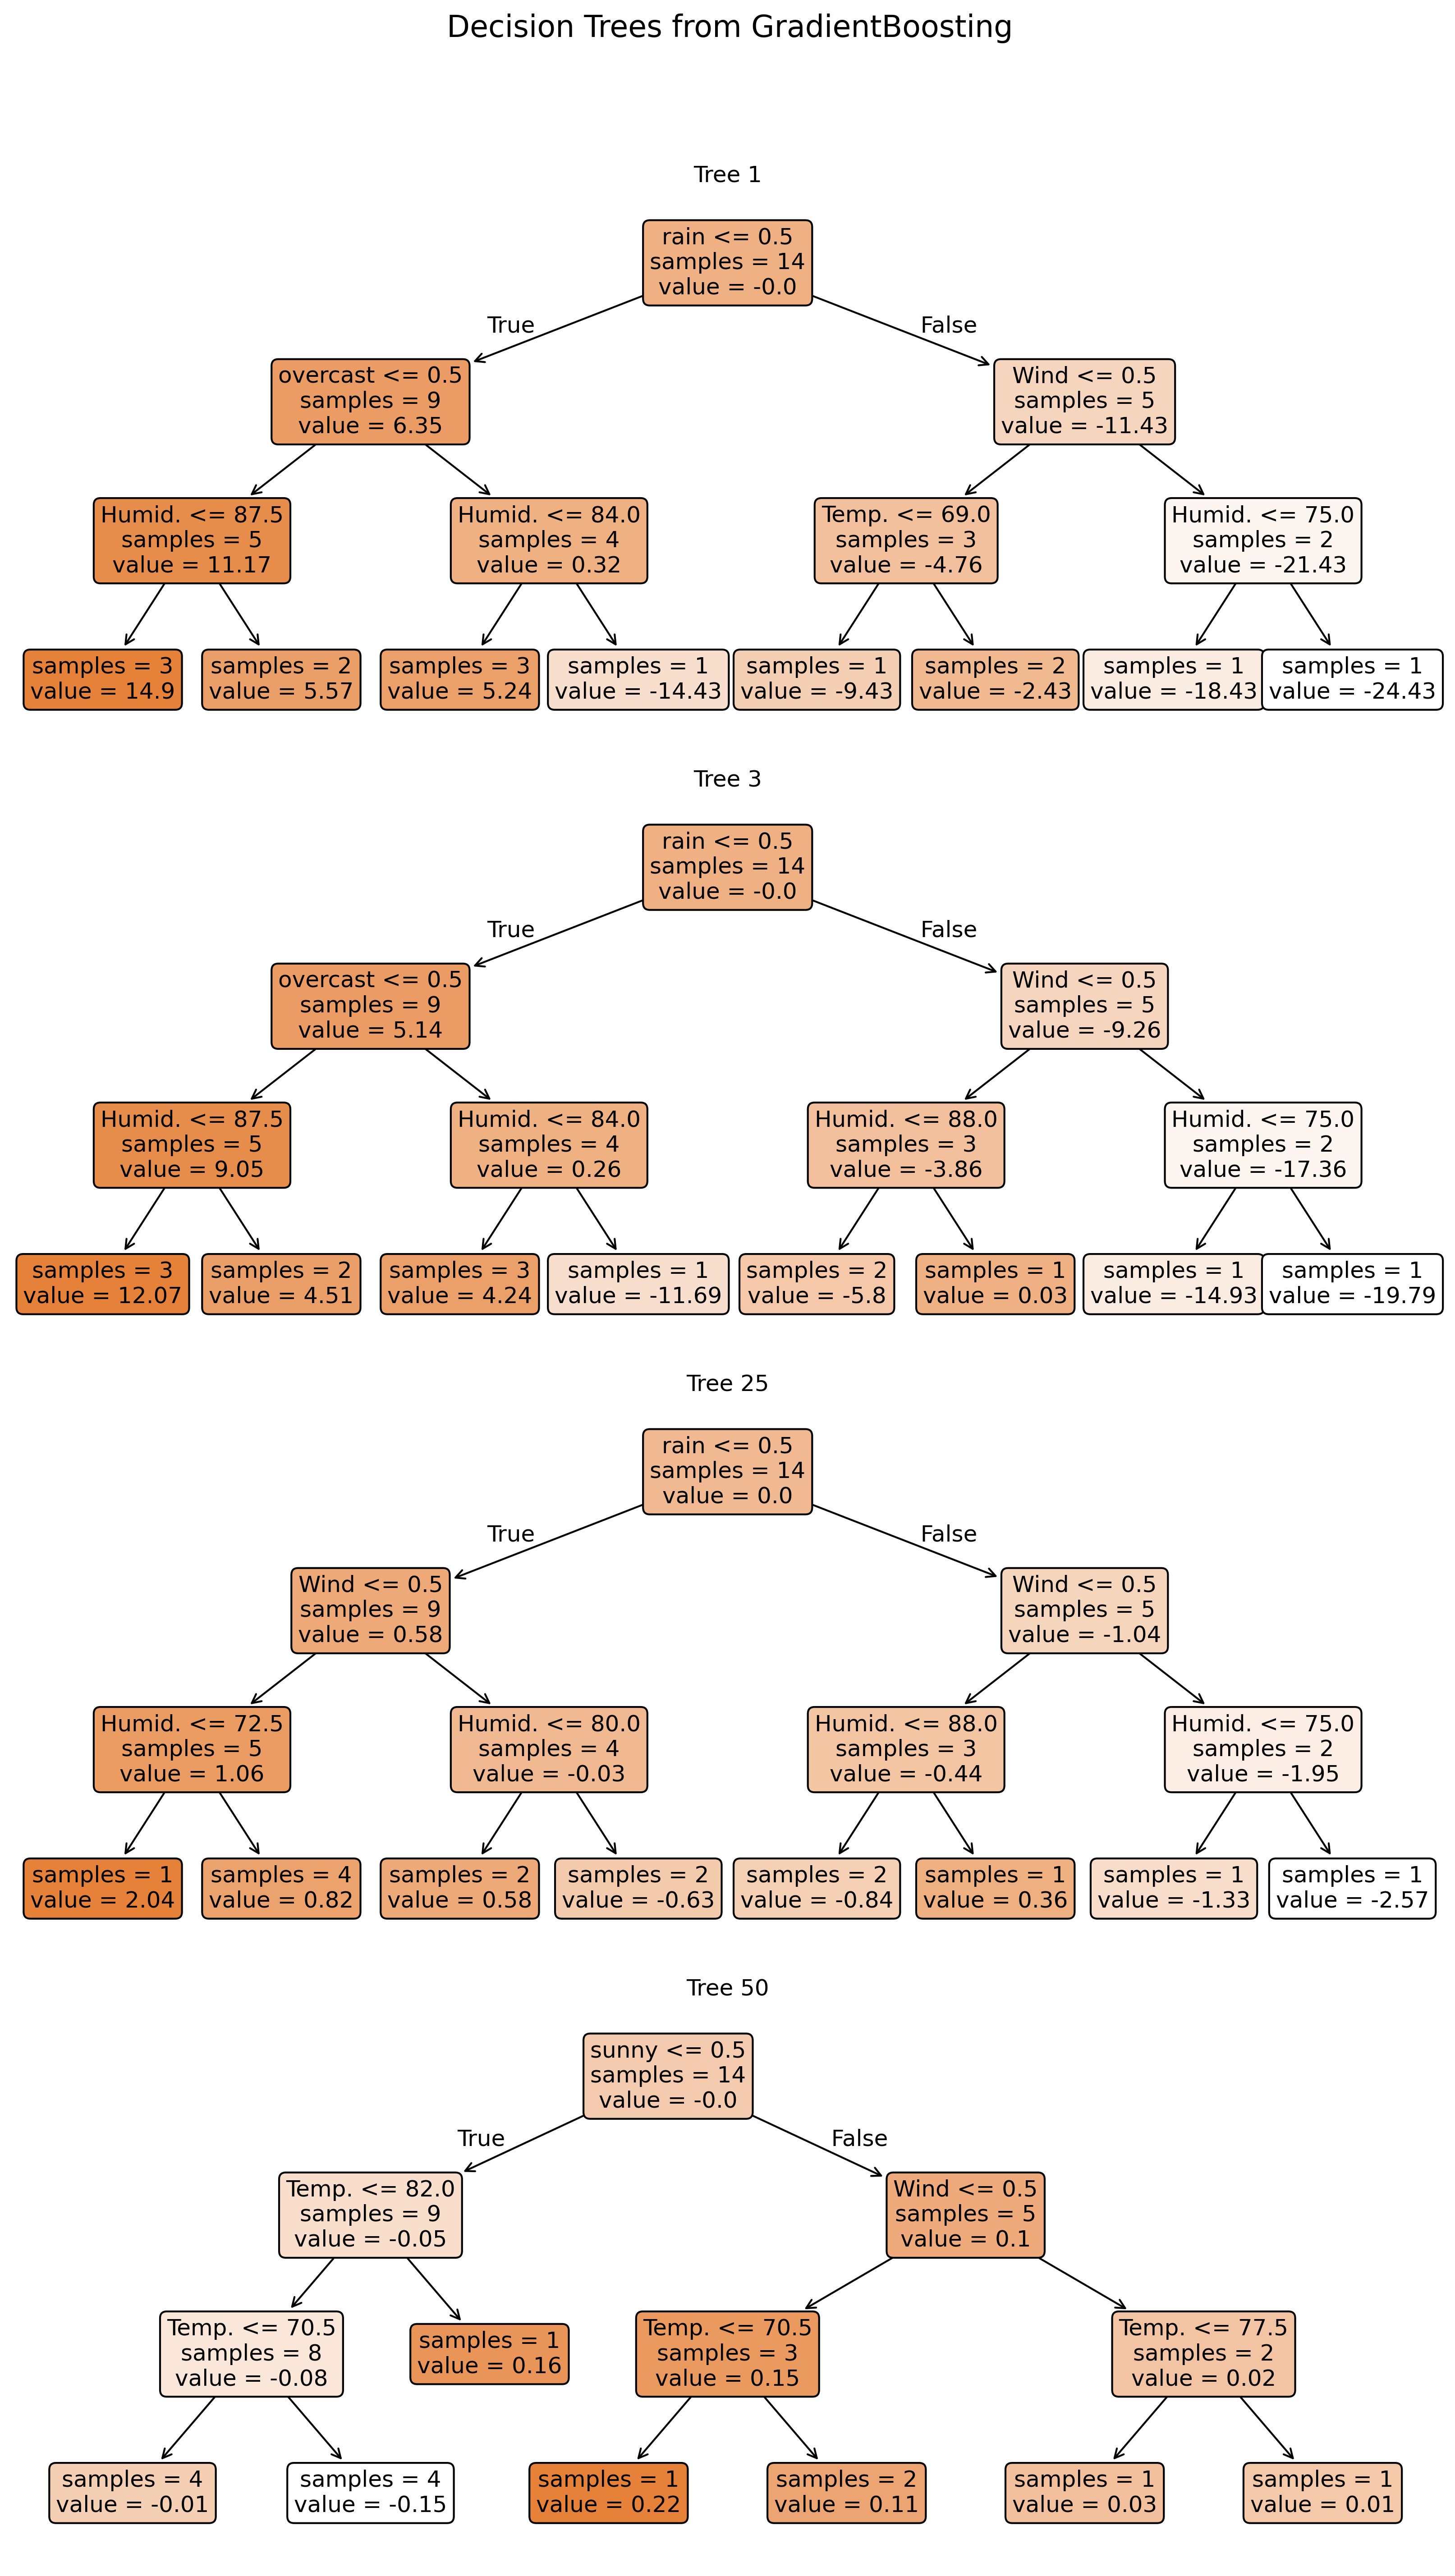

In [10]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Plot trees 1, 2, 49, and 50
plt.figure(figsize=(11, 20), dpi=300)

for i, tree_idx in enumerate([0, 2, 24, 49]):
    plt.subplot(4, 1, i+1)
    plot_tree(clf.estimators_[tree_idx,0], 
              feature_names=X_train.columns,
              impurity=False,
              filled=True, 
              rounded=True,
              precision=2,
              fontsize=12)
    plt.title(f'Tree {tree_idx + 1}')

plt.suptitle('Decision Trees from GradientBoosting', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Lets see the error of 1st and 50th model

In [16]:
from sklearn.metrics import mean_squared_error

# Get staged predictions
staged_preds = list(clf.staged_predict(X_test))

# RMSE for 1st model (index 0)
rmse_1 = np.sqrt(mean_squared_error(y_test, staged_preds[0]))

# RMSE for 25th model (index 24)
rmse_25 = np.sqrt(mean_squared_error(y_test, staged_preds[24]))

# RMSE for 50th model (index 49)
rmse_50 = np.sqrt(mean_squared_error(y_test, staged_preds[49]))

print(f"RMSE after 1st tree: {rmse_1}")
print(f"RMSE after 25th tree: {rmse_25}")
print(f"RMSE after 50th tree: {rmse_50}")

RMSE after 1st tree: 11.13750431055242
RMSE after 25th tree: 4.986500687941823
RMSE after 50th tree: 4.717941817377309


# Lets plot the RMSE

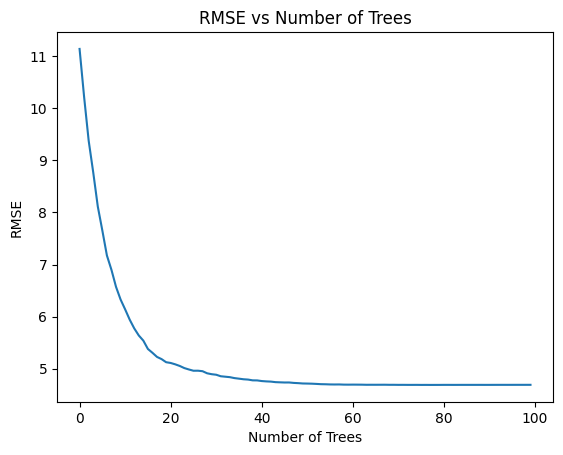

In [17]:
import matplotlib.pyplot as plt

rmse_list = []

for preds in clf.staged_predict(X_test):
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    rmse_list.append(rmse)

plt.plot(rmse_list)
plt.xlabel("Number of Trees")
plt.ylabel("RMSE")
plt.title("RMSE vs Number of Trees")
plt.show()

## Observation:
It seems that 40 models should be suffcient here for boosting

In [13]:
# Get predictions
y_pred = clf.predict(X_test)

# Create DataFrame with actual and predicted values
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
print(results_df) # Display results DataFrame

# Calculate and display RMSE
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse:.4f}")

    Actual  Predicted
14      33  38.992320
15      29  31.012362
16      25  32.991445
17      51  48.942655
18      41  46.819157
19      14  15.380151
20      34  26.808298
21      29  32.964361
22      49  49.265694
23      36  42.469100
24      57  52.881795
25      21  23.758305
26      23  28.147929
27      41  42.992096
RMSE: 4.6921
